## looking into author affiliation issues

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import requests

In [10]:
auths = pd.read_csv('../new oa comparison/OA_auths_20-24.csv')
auths.columns

Index(['OpenAlex ID', 'ORCID', 'Name', 'Alt Names', 'Publications',
       'Citations', 'h-index', 'Number of Institutions', 'Topic'],
      dtype='object')

In [11]:
display(auths['Number of Institutions'].describe())

count    7928.000000
mean       11.353935
std        35.702284
min         1.000000
25%         2.000000
50%         4.000000
75%        11.000000
max      1759.000000
Name: Number of Institutions, dtype: float64

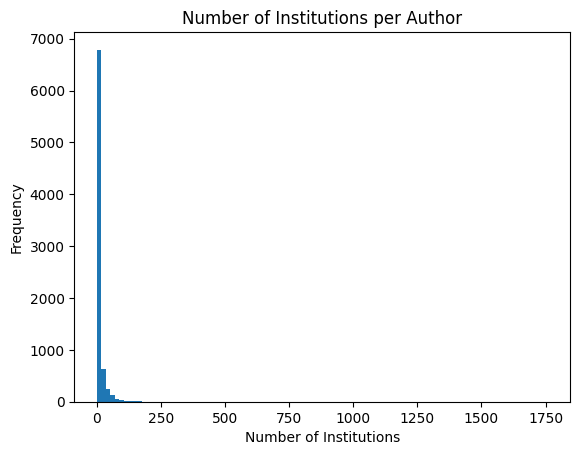

In [12]:
plt.hist(auths['Number of Institutions'], bins=100)
plt.title("Number of Institutions per Author")
plt.xlabel("Number of Institutions")
plt.ylabel("Frequency")
plt.show() 

In [13]:
auths.sort_values('Number of Institutions', ascending=False).head(20)

,OpenAlex ID,ORCID,Name,Alt Names,Publications,Citations,h-index,Number of Institutions,Topic
1320,A5108047889,https://orcid.org/0000-0001-5697-0717,Yi-Xiang Wang,"['A.H.M. Muntasir Billah', 'Ao Guo', 'Bernard\...",8193,27245,70,1759,Physical Sciences
1425,A5100437036,https://orcid.org/0000-0002-6170-4744,Kai Wang,"['Anzhen Wang', 'Binyu Song', 'Di Lu', 'Feng R...",7226,216635,172,1314,Life Sciences
6567,A5100399276,https://orcid.org/0000-0002-0166-1973,Han Zhang,"['Ahmed A. Al-Ghamdi', 'Chris Bowen', 'Dan He'...",3869,157203,184,809,Physical Sciences
4119,A5100345153,https://orcid.org/0000-0001-5286-4423,Qing Liu,"['Chunyan Yu', 'Dimitrios Alexopoulos', 'LIU, ...",3213,63673,107,651,Physical Sciences
2924,A5110516399,https://orcid.org/0000-0001-6036-2685,Xin Zhang,"['Chaoran Zhou', 'Chen Li', 'Haomiao Li', 'Hua...",1664,34700,87,577,Life Sciences
2057,A5100444820,https://orcid.org/0000-0002-7929-5889,Xiaogang Wang,"['A Valenzuela', 'C. Li', 'Congyi Hao', 'Hongs...",3830,254473,209,547,Physical Sciences
7847,A5018419311,https://orcid.org/0000-0003-4776-5601,Salim Yusuf,"['AC Mattos', 'David Fitchett', 'J Potter', 'J...",2144,291160,262,448,Health Sciences
4393,A5100327582,https://orcid.org/0000-0003-2000-858X,Xin Zhang,"['Cao, Jian-Jun', 'Chengwei Zhang', 'Guangshe ...",1563,33997,83,427,Physical Sciences
6429,A5100431366,https://orcid.org/0000-0003-1723-4746,Rui Wang,"['FENG WANG', 'Feng Wang', 'Feng Wang -', 'Fen...",885,25906,69,389,Health Sciences
1521,A5100353780,https://orcid.org/0000-0002-0041-3134,Xin Li,"['<p>Xin Li, Guoqiang Tang, Yumei Ren, Xuchang...",1050,14738,54,387,Physical Sciences


for top 100 authors by affiliation count we can pull the full data

In [14]:
top_100_id = auths.sort_values('Number of Institutions', ascending=False).head(100)['OpenAlex ID'].tolist()
top_100_id

['A5108047889',
 'A5100437036',
 'A5100399276',
 'A5100345153',
 'A5110516399',
 'A5100444820',
 'A5018419311',
 'A5100327582',
 'A5100431366',
 'A5100353780',
 'A5094302920',
 'A5100329932',
 'A5094361178',
 'A5100397026',
 'A5115590906',
 'A5115695469',
 'A5100389268',
 'A5100333516',
 'A5100333538',
 'A5100336427',
 'A5114861068',
 'A5035068594',
 'A5100343513',
 'A5100658008',
 'A5100318419',
 'A5100354297',
 'A5100407381',
 'A5100371992',
 'A5025023257',
 'A5100636534',
 'A5100728059',
 'A5034363861',
 'A5100398805',
 'A5100371434',
 'A5100348260',
 'A5100343450',
 'A5050936489',
 'A5100444288',
 'A5100351927',
 'A5100336830',
 'A5100389108',
 'A5100366890',
 'A5009177807',
 'A5100395351',
 'A5100398804',
 'A5100452334',
 'A5100351907',
 'A5100374822',
 'A5041759678',
 'A5086059428',
 'A5050932952',
 'A5100708422',
 'A5022813675',
 'A5053840112',
 'A5100614211',
 'A5058205892',
 'A5025082628',
 'A5101984481',
 'A5034708845',
 'A5110273945',
 'A5118899500',
 'A5100336360',
 'A50477

In [ ]:
top_100_full = []

for id in top_100_id:
    url = f"https://api.openalex.org/authors/{id}"
    response = requests.get(url)
    response_json = response.json()
    top_100_full.append(response_json)

top_100_full = pd.DataFrame(top_100_full)


In [24]:
top_100_full.head(100)

,id,orcid,display_name,raw_author_names,full_name,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,topic_share,x_concepts,counts_by_year,display_name_alternatives,block_key,works_api_url,updated_date,created_date
0,https://openalex.org/A5108047889,https://orcid.org/0000-0001-5697-0717,Yi-Xiang Wang,"[A.H.M. Muntasir Billah, Ao Guo, Bernard S. Ma...",J Yi-Xiang Wang,9087,27387,"{'2yr_mean_citedness': 0.27348099016937105, 'h...",{'openalex': 'https://openalex.org/A5108047889...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I100135526', 'ro...","[{'id': 'https://openalex.org/T10018', 'displa...","[{'id': 'https://openalex.org/T11297', 'displa...","[{'id': '71924100', 'wikidata': 'https://www.w...","[{'year': 1988, 'works_count': 1, 'oa_works_co...","[A.H.M. Muntasir Billah, Ao Guo, Bernard S. Ma...",j wang,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00
1,https://openalex.org/A5100437036,https://orcid.org/0000-0002-6170-4744,Kai Wang,"[Anzhen Wang, Binyu Song, Di Lu, Feng Rong, Fe...",Kai You Wang,7226,217052,"{'2yr_mean_citedness': 5.534090909090909, 'h_i...",{'openalex': 'https://openalex.org/A5100437036...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I108688024', 'ro...","[{'id': 'https://openalex.org/T11287', 'displa...","[{'id': 'https://openalex.org/T10261', 'displa...","[{'id': '185592680', 'wikidata': 'https://www....","[{'year': 1976, 'works_count': 1, 'oa_works_co...","[Anzhen Wang, Binyu Song, Di Lu, Feng Rong, Fe...",k wang,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00
2,https://openalex.org/A5100399276,https://orcid.org/0000-0002-0166-1973,Han Zhang,"[Ahmed A. Al-Ghamdi, Chris Bowen, Dan He, H L ...",Han Zhang,3874,157560,"{'2yr_mean_citedness': 6.723700887198986, 'h_i...",{'openalex': 'https://openalex.org/A5100399276...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I11838497', 'ror...","[{'id': 'https://openalex.org/T10988', 'displa...","[{'id': 'https://openalex.org/T10275', 'displa...","[{'id': '185592680', 'wikidata': 'https://www....","[{'year': 1987, 'works_count': 6, 'oa_works_co...","[Ahmed A. Al-Ghamdi, Chris Bowen, Dan He, H L ...",h zhang,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00
3,https://openalex.org/A5100345153,https://orcid.org/0000-0001-5286-4423,Qing Liu,"[Chunyan Yu, Dimitrios Alexopoulos, LIU, Qing,...",Qing Huo Liu,3214,63807,"{'2yr_mean_citedness': 5.696428571428571, 'h_i...",{'openalex': 'https://openalex.org/A5100345153...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I127108677', 'ro...","[{'id': 'https://openalex.org/T11263', 'displa...","[{'id': 'https://openalex.org/T11263', 'displa...","[{'id': '192562407', 'wikidata': 'https://www....","[{'year': 1982, 'works_count': 1, 'oa_works_co...","[Chunyan Yu, Dimitrios Alexopoulos, LIU, Qing,...",q liu,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00
4,https://openalex.org/A5110516399,https://orcid.org/0000-0001-6036-2685,Xin Zhang,"[Chaoran Zhou, Chen Li, Haomiao Li, Hua Zhou, ...",Xin Zhang,1664,34777,"{'2yr_mean_citedness': 5.5482625482625485, 'h_...",{'openalex': 'https://openalex.org/A5110516399...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I1793135', 'ror'...","[{'id': 'https://openalex.org/T10515', 'displa...","[{'id': 'https://openalex.org/T11765', 'displa...","[{'id': '71924100', 'wikidata': 'https://www.w...","[{'year': 1983, 'works_count': 1, 'oa_works_co...","[Chaoran Zhou, Chen Li, Haomiao Li, Hua Zhou, ...",x zhang,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,https://openalex.org/A5101839638,https://orcid.org/0000-00

In [26]:
top_100_full[top_100_full['display_name'] == 'Stephen A. Spector']

,id,orcid,display_name,raw_author_names,full_name,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,topic_share,x_concepts,counts_by_year,display_name_alternatives,block_key,works_api_url,updated_date,created_date
67,https://openalex.org/A5017306542,https://orcid.org/0000-0002-1882-4855,Stephen A. Spector,"[Gary Sinclair, S A Spector, S Spector, S. A. ...",Stephen A. Spector,408,25871,"{'2yr_mean_citedness': 3.3529411764705883, 'h_...",{'openalex': 'https://openalex.org/A5017306542...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I36258959', 'ror...","[{'id': 'https://openalex.org/T10112', 'displa...","[{'id': 'https://openalex.org/T10112', 'displa...","[{'id': '71924100', 'wikidata': 'https://www.w...","[{'year': 1936, 'works_count': 1, 'oa_works_co...","[Gary Sinclair, S A Spector, S Spector, S. A. ...",s spector,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00


In [27]:
top_100_full[top_100_full['display_name'] == 'Ke Li']

,id,orcid,display_name,raw_author_names,full_name,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,topic_share,x_concepts,counts_by_year,display_name_alternatives,block_key,works_api_url,updated_date,created_date
22,https://openalex.org/A5100343513,https://orcid.org/0000-0002-7873-1554,Ke Li,"[Jingyuan Wan, K. Li, Ke LI, Ke Li, Ke Li (106...",Kun Li,519,10002,"{'2yr_mean_citedness': 3.1597222222222223, 'h_...",{'openalex': 'https://openalex.org/A5100343513...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I173759888', 'ro...","[{'id': 'https://openalex.org/T10036', 'displa...","[{'id': 'https://openalex.org/T10036', 'displa...","[{'id': '86803240', 'wikidata': 'https://www.w...","[{'year': 1987, 'works_count': 1, 'oa_works_co...","[Jingyuan Wan, K. Li, Ke LI, Ke Li, Ke Li (106...",k li,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00
35,https://openalex.org/A5100343450,https://orcid.org/0000-0001-7200-4244,Ke Li,"[KE LI, Ke LI, Ke Li, Ke Li*, Ke 珂 Li 李, Ke, L...",Ke Li*,470,8529,"{'2yr_mean_citedness': 4.594594594594595, 'h_i...",{'openalex': 'https://openalex.org/A5100343450...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I23923803', 'ror...","[{'id': 'https://openalex.org/T10848', 'displa...","[{'id': 'https://openalex.org/T10848', 'displa...","[{'id': '41008148', 'wikidata': 'https://www.w...","[{'year': 1990, 'works_count': 1, 'oa_works_co...","[KE LI, Ke LI, Ke Li, Ke Li*, Ke 珂 Li 李, Ke, L...",k li*,https://api.openalex.org/works?filter=author.i...,2026-07-04T12:17:28,2016-06-24T00:00:00


In [28]:
list(top_100_full['display_name'])

['Yi-Xiang Wang',
 'Kai Wang',
 'Han Zhang',
 'Qing Liu',
 'Xin Zhang',
 'Xiaogang Wang',
 'Salim Yusuf',
 'Xin Zhang',
 'Rui Wang',
 'Xin Li',
 'Druck Stückle',
 'Xi Chen',
 'Franz Printing',
 'Hao Zhang',
 'Jie Yang',
 'Yi Wang',
 'Gang Chen',
 'Lei Chen',
 'Lei Chen',
 'Long Chen',
 'Yue Wang',
 'Mark A. Rubin',
 'Ke Li',
 'Shujun Zhang',
 'Wei Li',
 'Cheng Li',
 'Dong Liu',
 'Yue Wang',
 'Manolis Kogevinas',
 'Jiaxing Li',
 'Steven J.M. Jones',
 'Viswanathan Mohan',
 'Kun Liu',
 'Brian Lee',
 'Yi‐Ting Chen',
 'Ke Li',
 'Koon Teo',
 'Dongho Kim',
 'Lin Zhang',
 'Jing Li',
 'Yanyan Zhang',
 'Shuo Chen',
 'Jim Williams',
 'Yiming Zhang',
 'Kun Liu',
 'Hao Ma',
 'Lin Zhang',
 'Yufei Wang',
 'Sidney H. Kennedy',
 'Ruth Ann Marrie',
 'George Tomlinson',
 'Rebecca Lee',
 'Amiram Gafni',
 'Wayne Hall',
 'Ke Wang',
 'Sonia S. Anand',
 'David D.L. Bowtell',
 'Hua Yang',
 'Alan Katz',
 'Ying Yu',
 'J. Kroll',
 'Long Chen',
 'Inderbir S. Gill',
 'Marco A. Marra',
 'Xin Tong',
 'Murray Krahn',


In [29]:
top_100_full[top_100_full['display_name'] == 'Robert S. Hogg']

,id,orcid,display_name,raw_author_names,full_name,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,topic_share,x_concepts,counts_by_year,display_name_alternatives,block_key,works_api_url,updated_date,created_date
73,https://openalex.org/A5034865907,https://orcid.org/0000-0003-3463-5488,Robert S. Hogg,"[, B Hogg, Hogg, R, Hogg, R.S., Hogg, RS, Hogg...","Hogg, Robert Stephen",816,48845,"{'2yr_mean_citedness': 1.7027027027027026, 'h_...",{'openalex': 'https://openalex.org/A5034865907...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...","[{'id': 'https://openalex.org/T10082', 'displa...","[{'id': 'https://openalex.org/T10082', 'displa...","[{'id': '71924100', 'wikidata': 'https://www.w...","[{'year': 1851, 'works_count': 1, 'oa_works_co...","[, B Hogg, Hogg, R, Hogg, R.S., Hogg, RS, Hogg...",r hogg,https://api.openalex.org/works?filter=author.i...,2026-07-05T12:17:18,2016-06-24T00:00:00
